<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II


## Tensões principais

### Problema 5

Uma viga construída com um perfil W250 $\times$ 49.1 suporta as quatro forças indicadas na figura, expressas em kN, que estão alinhadas com os eixos $x$, $y$ e $z$ do referencial.

**a)** Determine a distribuição de tensões normais na secção que contém o ponto A, representando a posição do eixo neutro e calculando o valor da tensão normal máxima e mínima.

**b)** Obtenha as tensões principais no ponto A e o valor da tensão de corte máxima nesse ponto.

**c)** Indique as três direções principais do estado de tensão no ponto A.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au07/P5/MSII_Au07_P5.png"
width="400">

### Resolução


In [21]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

cor = '2'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

# data structure, units: N, mm, MPa

class varin: pass

d = varin()
d.x1 = 500.e-3 # unit: m
d.x2 = 100.e-3 # unit: m
d.Px = 100.*1e3 # unit: N/m
d.Py = 25.*1e3 # unit: N/m
d.Pz = 8.*1e3 # unit: N/m

w250 = varin()
w250.h = 247.e-3 # unit: m
w250.b = 202.e-3 # unit: m
w250.A = .625e-2 # unit: m2
w250.Iz = 70.6e-6 # unit: m4
w250.Iy = 15.16e-6 # unit: m4
w250.ew = 3.7e-3
w250.eb = 11.e-3 # unit: m


#### **a)** Determine a distribuição de tensões normais na secção que contém o ponto A, representando a posição do eixo neutro e calculando o valor da tensão normal máxima e mínima.

#### Sistema força-binário equivalente

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au07/P5/MSII_Au07_P5a.png"
width="500">

- Esforço axial, $N$

\begin{equation*}
N = - P_x
\end{equation*}

In [22]:
N = -d.Px
print(f'N = {N:.1f} [N]')

N = -100000.0 [N]


- Esforço transverso na direção $y$, $V_y$

\begin{equation*}
V_y = P_y
\end{equation*}

In [23]:
Vy = d.Py
print(f'Vy = {Vy:.1f} [N]')

Vy = 25000.0 [N]


- Esforço transverso na direção $z$, $V_z$

\begin{equation*}
V_z = 2 P_z
\end{equation*}

In [24]:
Vz = 2*d.Pz
print(f'Vz = {Vz:.1f} [N]')

Vz = 16000.0 [N]


- Momento resultante das forças segundo o eixo $x$, $M_x(\equiv T)$

Apenas as forças ortogonais a $x$ exercem momento torsor,

\begin{equation*}
T = 0
\end{equation*}

In [25]:
T = 0
print(f'T = {T:.1f} [N.m]')

T = 0.0 [N.m]


- Momento fletor em torno do eixo $y$, $M_y$

Por definição de momento de uma força, só exercem momento de flexão em relação ao eixo $y$, as forças que são coplanares com o plano $x-z$ que lhe é perpendicular. Neste caso, apenas a força $P_z$ contribui para $M_y$.

\begin{equation*}
M_y = - 2(P_{z} \cdot x_L)
\end{equation*}

com

- $\vec{r}_{\vec{P_z}} = x_L~\vec{\imath} ~\wedge~ \vec{P}_z = P_z~\vec{k}  \quad\therefore\quad -P_z x_L~\vec{\jmath}$

In [26]:
d_ = d.x1 + d.x2
My = -2*d_*d.Pz
print(f'My = -({d_:.3f}){2*d.Pz:.1f} = {My:.1f} [N.m]')

My = -(0.600)16000.0 = -9600.0 [N.m]


- Momento fletor em torno do eixo $z$, $M_z$

As forças de exercem momento em relação ao eixo $z$ são as forças contidas no plano $x-y$, $P_x$, $P_y$:

\begin{equation*}
M_z = P_x (h/2) + P_y (x_L)
\end{equation*}

com

- $\vec{r}_{\vec{P_x}} = h/2~\vec{\jmath} ~\wedge~ \vec{P}_x = -P_x~\vec{\imath} \quad\therefore\quad P_x (h/2)~\vec{k}$
- $\vec{r}_{\vec{P_y}} = x_L~\vec{\imath} ~\wedge~ \vec{P}_y = P_y~\vec{\jmath} \quad\therefore\quad P_y (x_L)~\vec{k}$

In [27]:
Mz = w250.h/2*d.Px + d.x1*d.Py
print(f'Mz = ({w250.h/2:.3f}){d.Px:.1f} + ({d.x1:.3f}){d.Py:.1f}  = {Mz:.1f} [N.m]')

Mz = (0.123)100000.0 + (0.500)25000.0  = 24850.0 [N.m]


- Área da secção

In [28]:
A = w250.A
print(f'A (w250x49.1) = {A:.3e} [m^2]')

A (w250x49.1) = 6.250e-03 [m^2]


- Momento de inércia em relação ao eixo $z$, $I_z$

In [29]:
Iz = w250.Iz
print(f'Iz (w250x49.1) = {Iz:.3e} [m^4]')

Iz (w250x49.1) = 7.060e-05 [m^4]


- Momento de inércia em relação ao eixo $y$, $I_y$

In [30]:
Iy = w250.Iy
print(f'Iy (w250x49.1) = {Iy:.3e} [m^4]')

Iy (w250x49.1) = 1.516e-05 [m^4]


#### Esforço combinado

Neste cenário de carregamento excêntrico, pelo princípio de Saint-Venant, as tensões normais numa secção suficientemente afastada das extremidades da barra (devido a efeito de concentração de tensões) podem ser calculadas, atendendo ainda ao princípio da sobreposição, por:

\begin{equation*}
\sigma_{xx} = - \frac{|N|}{A} - \frac{|M_z|}{I_z}y - \frac{|M_y|}{I_y} z
\end{equation*}

De notar que o momento fletor $M_z$ é positivo, contudo o momento fletor $M_y$ é negativo.

In [31]:
y, z, sigx = sy.symbols('y z sigx')

eqsigx = N/A - np.abs(Mz)/Iz*y - np.abs(My)/Iy*z
Eq = sigx - eqsigx
print(f'Eq = {Eq}')
sigxx = solve(Eq,sigx)[0]
print(f'sigxx(y,z)  = {sigxx*1e-6} [MPa]')

Eq = sigx + 351983002.832861*y + 633245382.585752*z + 16000000.0
sigxx(y,z)  = -351.983002832861*y - 633.245382585752*z - 16.0 [MPa]


In [32]:
yzfun = solve(sigxx,y)[0]
print(f'y = {yzfun} (recta geométrica do eixo neutro) [m]')
print(f'z = {solve(sigxx,z)[0]} (recta geométrica do eixo neutro) [m]')

y = -1.79907943704443*z - 0.045456740442656 (recta geométrica do eixo neutro) [m]
z = -0.555839825306893*y - 0.0252666666666667 (recta geométrica do eixo neutro) [m]


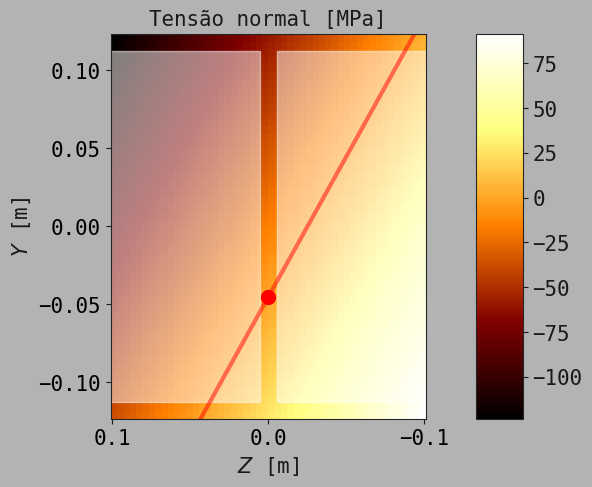

In [33]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Rectangle

zsiz = np.linspace(w250.b/2,-w250.b/2)
ysiz = np.linspace(w250.h/2,-w250.h/2)
Z, Y = np.meshgrid(zsiz, ysiz)

def tensnormal(y2,z2):
    return sigxx.subs({(y,y2),(z,z2)}) #- eval_NAB/A - eval_MzAB/Iz*y + eval_MyAB/Iy*z

SxxMap = np.zeros(np.shape(Z))
for i in range(0,len(ysiz)):
    for j in range(0,len(zsiz)):
        SxxMap[i,j] = tensnormal(ysiz[i],zsiz[j])

zplo = zsiz
yplo = np.zeros(len(zplo))
for i in range(0,len(zplo)):
    yplo[i] = yzfun.subs(z,zplo[i])

fzp = 15
# Visualizacao u1(X1,X2,X3,t1)
fig = plt.figure(figsize=(10, 5))
ax  = plt.gca()
ttl = plt.title('Tensão normal [MPa]',fontsize=15)
ttl.set_position([0.5, 1.05])
plt.xlim([1.*w250.b/2,-1.*w250.b/2])
plt.ylim([-1.*w250.h/2,1.*w250.h/2])
plt.ylabel(r'$Y$ [m]',fontsize=fzp)
plt.xlabel(r'$Z$ [m]',fontsize=fzp)
im = ax.imshow(SxxMap*1e-6, extent=[w250.b/2, -w250.b/2, -w250.h/2,w250.h/2], cmap="afmhot")
# ax.add_patch(Rectangle((-w250.b/2+0.*w250.ew, -w250.h/2+1.*w250.ew), w250.b/2+10*w250.ew, w250.h-2*w250.ew,color="white",alpha=0.5))
ax.add_patch(Rectangle((w250.eb/2, -w250.h/2+w250.eb), w250.b/2+10*w250.eb, w250.h-2*w250.eb,color="white",alpha=0.5))
ax.add_patch(Rectangle((-w250.eb/2, -w250.h/2+w250.eb), -w250.b/2-2.*w250.eb, w250.h-2*w250.eb,color="white",alpha=0.5))
plt.plot(zplo,yplo,'r-',linewidth=3,alpha=0.5)
ax.plot(0,yzfun.subs(z,0),'or',markersize=10)
plt.xticks(color ='k', size=fzp)
plt.yticks(color ='k', size=fzp)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="15%", pad=0.5)
cbar = plt.colorbar(im, cax=cax, orientation = "vertical")
cbar.ax.tick_params(labelsize=fzp)
plt.show()

In [34]:
ymax_, zmax_ = w250.h/2, w250.b/2
sigmax_ = tensnormal(ymax_,zmax_)
print(f'sig.max :: (y = {ymax_}, z = {zmax_}) :: {sigmax_*1e-6:.2f} [MPa]')

ymin_, zmin_ = -w250.h/2, -w250.b/2
sigmin_ = tensnormal(ymin_,zmin_)
print(f'sig.min :: (y = {ymin_}, z = {zmin_}) :: {sigmin_*1e-6:.2f} [MPa]')

sig.max :: (y = 0.1235, z = 0.101) :: -123.43 [MPa]
sig.min :: (y = -0.1235, z = -0.101) :: 91.43 [MPa]


#### **b)** Obtenha as tensões principais no ponto A e o valor da tensão de corte máxima nesse ponto.

- Tensão normal no ponto A:

In [35]:
yA, zA = -w250.h/2, 0
sigA = tensnormal(yA, zA)
print(f'sig.A :: (y = {yA:.4f}, z = {zA:.1f}) :: {sigA*1e-6:.2f} [MPa]')


sig.A :: (y = -0.1235, z = 0.0) :: 27.47 [MPa]


- Tensão de corte no ponto A devido aos esforços tranversos $V_y$, e $V_z$:

Considere-se o ponto A pertencente ao eixo $y$. Note-se que, em relação à ação do esforço transverso $V_y$, este é um ponto de descontinuidade para a tensão de corte $\tau_{xz}$. De facto, é de notar que o corte da secção contendo o ponto A conduz a $Q_z = 0$, ou seja, a uma distribuição equidistante da área em relação ao eixo do $z$. Isso implica que a contribuição $\tau_{xz}^A(V_y)$ seja nula. Nesse sentido, nesta proposta de resolução, apenas se considerará $\tau_{xz}^A$ devido ao esforço transverso $V_{z}$.

- Tensão de corte no ponto A devida apenas ao esforço transverso $V_z$:

\begin{equation*}
\tau_{xz}^A = \left| \frac{V_zQ_y}{I_yt_b} \right|
\quad\wedge\quad Q_y = \int_A^* z\,\mathrm{d}A = A^*\overline{z} = \sum_i A_i^*\overline{z}_i
\end{equation*}

De notar que:

- $V_z$ : é considerado positivo nesta equação como sendo positivo em relação aos eixos coordenados;
- $Q_y$ : é o primeiro momento de área da região obtida após corte da secção no ponto A ($A_i^*,~\overline{z}_i > 0)$.
- $t_b$ : de notar que neste tipo de perfil considera-se apenas a espessura no banzo para a determinação da tensão de corte $\tau_{xz}$, apesar do corte para o cálculo de $Q_y$ considerar a altura total do perfil.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au07/P5/MSII_Au07_P5b.png"
width="500">

In [36]:
Ay1_A = w250.b/2*w250.eb
print(f'Ay1_A = {w250.b/2:.3f}x{w250.eb:.3f} = {Ay1_A:.3e} [m²]')
z1_A = w250.b/2/2
print(f'z1_A = {z1_A:.3e} [m]')
Qy1_A = 2*Ay1_A*z1_A
print(f'Qy1_A = 2(Ay1_A*z1_A) = {Qy1_A:.3e} [m³]')
Ay2_A = (w250.h-2*w250.eb)*w250.ew
print(f'Ay2_A = {w250.h-2*w250.eb:.3f}x{w250.ew:.3f} = {Ay2_A:.3e} [m²]')
z2_A = w250.ew/2
print(f'z2_A = {z2_A:.3e} [m]')
Qy2_A = Ay2_A*z2_A
print(f'Qy2_A = {Qy2_A:.3e} [m³]')
Qy_A = Qy1_A + Qy2_A
print(f'Qy_A = {Qy_A:.3e} [m³]')

Ay1_A = 0.101x0.011 = 1.111e-03 [m²]
z1_A = 5.050e-02 [m]
Qy1_A = 2(Ay1_A*z1_A) = 1.122e-04 [m³]
Ay2_A = 0.225x0.004 = 8.325e-04 [m²]
z2_A = 1.850e-03 [m]
Qy2_A = 1.540e-06 [m³]
Qy_A = 1.138e-04 [m³]


In [37]:
tA = 2*w250.eb
tauxz_Vz_A = np.abs(Vz*Qy_A)/Iy/tA
print(f'Vz = {Vz:.1f} [N]')
print(f'Qy = {Qy_A:.3e} [m³]')
print(f'Iy = {Iy:.3e} [m⁴]')
print(f't  = {2*w250.eb:.3e} [m]')
print(f'>>> Vz = {np.abs(Vz):.1f} \n:: tauxz_Vz_A = {tauxz_Vz_A*1e-6:.3f} [MPa]')

Vz = 16000.0 [N]
Qy = 1.138e-04 [m³]
Iy = 1.516e-05 [m⁴]
t  = 2.200e-02 [m]
>>> Vz = 16000.0 
:: tauxz_Vz_A = 5.457 [MPa]


- 
- Tensor das tensões num ponto material:

\begin{equation*}
[\sigma] =
\begin{bmatrix}
\sigma_{xx} & \tau_{xy} & \tau_{xz} \\
\tau_{xy} & \sigma_{yy} & \tau_{yz} \\
\tau_{xz} & \tau_{yz} & \sigma_{zz}
\end{bmatrix}
\end{equation*}

Para o ponto A: $\sigma_{yy}=\sigma_{zz}=0, \tau_{xy} = \tau_{yz} = 0$, resultando:

\begin{equation*}
[\sigma_A] =
\begin{bmatrix}
\sigma_{xx} & 0 & \tau_{xz} \\
0 & 0 & 0 \\
\tau_{xz} & 0 & 0
\end{bmatrix}
\quad\wedge~
\sigma_{xx}(y_A,z_A)
~\wedge~ \tau_{xz}^A = \frac{V_zQ_y}{I_yt_b}
\end{equation*}

ou,

\begin{equation*}
[\sigma_A] =
\begin{bmatrix}
- \displaystyle\frac{|N|}{A} + \frac{|M_z|}{I_z}y_A & 0 & \displaystyle \frac{V_zQ_y}{I_yt_b} \\
0 & 0 & 0 \\
\displaystyle \frac{V_zQ_y}{I_yt_b} & 0 & 0
\end{bmatrix}
\quad\textrm{[MPa]}
\end{equation*}

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au07/P5/MSII_Au07_P5c.png"
width="500">


In [38]:
np.set_printoptions(precision=4)

def tenstens(s11,s12,s13,s22,s23,s33):
    return np.array([[s11,s12,s13],[s12,s22,s23],[s13,s23,s33]], np.float64)

ttA = tenstens(sigA,0,tauxz_Vz_A,0,0,0)
print(f"ttA :: \n {np.array2string(ttA*1e-6, precision=2, floatmode='fixed')} [MPa]")

ttA :: 
 [[27.47  0.00  5.46]
 [ 0.00  0.00  0.00]
 [ 5.46  0.00  0.00]] [MPa]


#### **c)** Indique as três direções principais do estado de tensão no ponto A.

\begin{equation*}
[\sigma]_A = 
\begin{bmatrix}
\sigma_{xx} & \tau_{xz} \\
\tau_{xz} & \sigma_{zz} 
\end{bmatrix}
\begin{bmatrix}
27.47 & 5.46 \\
5.46 & 0.0
\end{bmatrix}
\end{equation*}

com $X = (\sigma_{xx}, +\tau_{xz})$. Notar que neste caso o sentido de rotação das tensões de corte é contrário ao sentido de rotação positivo em torno do eixo dos $y$, dado pela regra da mão da direita (rotação de $z$ para $x$ definindo positivamente o eixo $y$). Neste caso, de acodo com a convensão, a tensão de corte é marcada positivamente, $+\tau_{xz}$, no círculo de mohr.

A análise do círculo de Mohr permite determinar os valores máximos e mínimos das componentes normais das tensões num determinado plano de análise. Para o plano $(0,x,y)$ vem:

\begin{equation*}
\sigma_{\textrm{max/min}} = \sigma_{\textrm{I/II}} = \sigma_{\textrm{médio}} + R
= \frac{\sigma_{xx} + \sigma_{zz}}{2} \pm
\sqrt{\left(\frac{\sigma_{xx}-\sigma_{zz}}{2}\right)^2+\tau_{xz}^2 }
\end{equation*}

e,

\begin{equation*}
\theta^{\textrm{mohr}} = \arctan\left(\frac{2\tau_{xz}}{\sigma_{xx}}\right)
\end{equation*}

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au07/P5/Convenc_Sinal.png"
width="500">

In [39]:
sxx, szz, txz = float(sigA), 0., float(tauxz_Vz_A)

def raio(si,sj,tij):
    return np.sqrt( ((si-sj)/2)**2 + tij**2 )

def s1(si,sj,tij):
    return (si+sj)/2 + np.sqrt( ((si-sj)/2)**2 + tij**2 )

def s3(si,sj,tij):
    return (si+sj)/2 - np.sqrt( ((si-sj)/2)**2 + tij**2 )


raio = raio(sxx, szz, txz)
print(f'R = {raio*1e-6:.2f} [MPa]')
sI = s1(sxx, szz, txz)
print(f'sI = {sI*1e-6:.2f} [MPa]')
sIII = s3(sxx, szz, txz)
print(f'sIII = {np.abs(sIII)*1e-6:.2f} [MPa]')

ttAprinc = tenstens(sI,0,0,0,0,sIII)
print(f"\nttAprinc :: \n {np.array2string(ttAprinc*1e-6, precision=2, floatmode='fixed')} [MPa]")

print(f'tensão de corte máxima = {raio*1e-6:.2f} [MPa]')

def angprinc(sx,sy,txy):
     return np.arctan(2*txy/(sx-sy))

thetap = np.rad2deg(angprinc(sxx,szz,txz))/2
print(f'thetap = {thetap:.2f} [deg]')

R = 14.78 [MPa]
sI = 28.51 [MPa]
sIII = 1.04 [MPa]

ttAprinc :: 
 [[28.51  0.00  0.00]
 [ 0.00  0.00  0.00]
 [ 0.00  0.00 -1.04]] [MPa]
tensão de corte máxima = 14.78 [MPa]
thetap = 10.83 [deg]


---------------------------
Círculo de Mohr
---------------------------

PLANO x-z:

Ponto X (27.5,5.5) MPa
Ponto Y (0.0,-5.5) MPa

  Tensão normal mínima: -1.0 MPa
  Tensão normal mínima: 28.5 MPa
   Tensão normal média: 13.7 MPa
Tensão de corte máxima: 14.8 MPa
Tensão de corte mínima: -14.8 MPa
Ângulo direção principal: 10.8 deg
(tens. corte nulas; espaço físico)


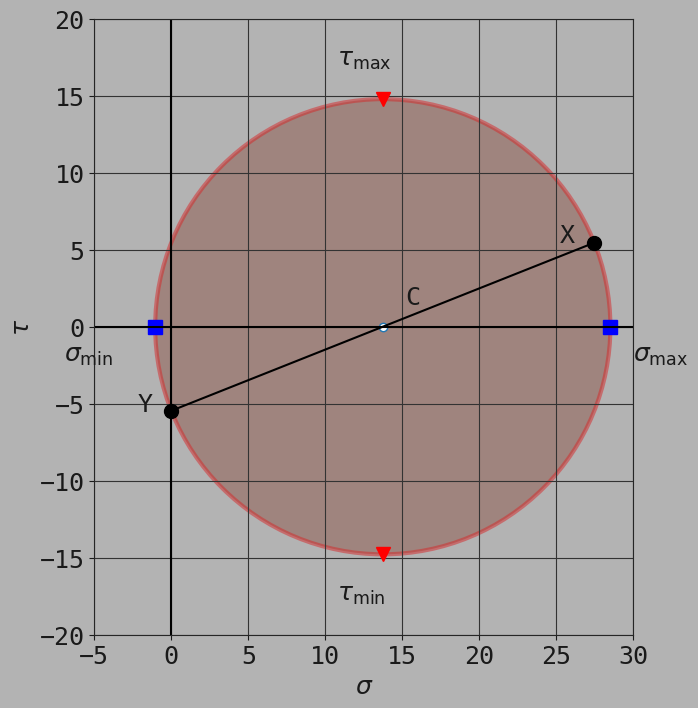

In [40]:
print('---------------------------')
print('Círculo de Mohr')
print('---------------------------')

def mohr(S,conv,limits,txt):
    fz = 10
    """Plot Mohr circle for a 2D tensor"""
    S11 = S[0][0]
    S12 = S[0][1]
    S22 = S[1][1]
    center = [(S11 + S22)/2.0, 0.0]
    radius = np.sqrt((S11 - S22)**2/4.0 + S12**2)
    Smin = center[0] - radius
    Smax = center[0] + radius
    # principal angle
    ang2tprinc = np.arctan(2*S12/(S11-S22))/2

    if txt == 1:
        if conv == 'counterclockwise':
            print(f'Ponto X ({S11:.1f},{-S12:.1f}) MPa')
            print(f'Ponto Y ({S22:.1f},{S12:.1f}) MPa\n')
        elif conv == 'clockwise':
            print(f'Ponto X ({S11:.1f},{S12:.1f}) MPa')
            print(f'Ponto Y ({S22:.1f},{-S12:.1f}) MPa\n')
        print(f'  Tensão normal mínima: {np.round(Smin,3):.1f} MPa')
        print(f'  Tensão normal mínima: {np.round(Smax,3):.1f} MPa')
        print(f'   Tensão normal média: {np.round(center[0], 3):.1f} MPa')
        print(f'Tensão de corte máxima: {np.round(radius, 3):.1f} MPa')
        print(f'Tensão de corte mínima: {np.round(-radius, 3):.1f} MPa')
        print(f'Ângulo direção principal: {np.round(np.rad2deg(ang2tprinc), 3):.1f} deg')
        print(f'(tens. corte nulas; espaço físico)')

    # plt.rcParams['axes.facecolor']='#7f7f7f'
    fig, ax = plt.subplots(figsize=(12,8))
    circ = plt.Circle((center[0],0), radius, facecolor='#8c564b', lw=3,
    edgecolor='#d62728', alpha = 0.5)
    desv = 0.1*radius
    plt.axis('image')
    ax = plt.gca()
    ax.add_artist(circ)
    ax.set_xlim(Smin - .3*radius, Smax + .3*radius)
    ax.set_ylim(-1.3*radius, 1.3*radius)
    plt.plot(Smin, 0, 'bs', markersize= fz)
    plt.plot(Smax, 0, 'bs', markersize= fz)
    plt.plot(center[0], radius, 'rv', markersize= fz)
    plt.plot(center[0], -radius, 'rv', markersize= fz)
    plt.plot(center[0], center[1], 'o', mfc='w')
    plt.text(center[0]+desv, desv, 'C')
    if conv == 'counterclockwise':
        plt.plot([S11, S22], [-S12, S12], 'ko', markersize= fz)
        plt.plot([S11, S22], [-S12, S12], 'k', markersize= fz)
        plt.text(S11 - .5*desv, -S12 , 'X')
        plt.text(S22 - .5*desv, S12, 'Y')
    elif conv == 'clockwise':
        plt.plot([S11, S22], [S12, -S12], 'ko', markersize= fz)
        plt.plot([S11, S22], [S12, -S12], 'k', markersize= fz)
        plt.text(S11 - 1.5*desv, S12 , 'X')
        plt.text(S22 - 1.5*desv, -S12, 'Y')
    plt.text(Smin - 0.4*radius, -0.15*radius, r'$\sigma_\mathrm{min}$')
    plt.text(Smax + desv, -0.15*radius, r'$\sigma_\mathrm{max}$')
    plt.text(center[0]-2*desv, 1.15*radius, r'$\tau_\mathrm{max}$')
    plt.text(center[0]-2*desv, -1.2*radius, r'$\tau_\mathrm{min}$')
    plt.xlabel(r"$\sigma$", size=18)
    plt.ylabel(r"$\tau$", size=18)
    plt.xlim(limits[0,0],limits[0,1])
    plt.ylim(limits[1,0],limits[1,1])
    ax.axhline(y=0, color='k')
    ax.axvline(x=0, color='k')
    ax.grid()
    plt.show()

S = ttA*1e-6
axislim = np.array([[-5,30],[-20,20]])
print('\nPLANO x-z:\n')
S11 = S[0,0]
S12 = S[0,2]
S22 = S[2,2]

mohr(np.array([[S11, S12],[S12, S22]]),'clockwise',axislim, 1)

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au07/P5/MSII_Au07_P5d.png"
width="500">

### Apêndice A. Circunferência de Mohr.

A circunferência de Mohr é uma representação gráfica da transformação do estado de tensão num ponto
introduzida pelo Eng. Alemão Otto Mohr (1835-1918). Esta representação gráfica pode iniciar-se pelo conhecimento das
componentes do tensor das tensões num determinado sistema de coordenadas. Considere-se o plano $(\sigma,\tau)$.
A partir das posições de dois pontos, $A$ e $B$, correspondentes às tensões normal e tangencial em duas
facetas ortogonais (estado plano de tensão), é possível definir um círculo cujo diâmetro é definido pelo segmento de
reta $\overline{AB}$. Desta figura geométrica
podem extraem-se duas dimensões: (i) a posição do centro da circunferência, $C$;
(ii) o valor do raio da circunferência, $R$. Das relações geométricas têm-se, por exemplo,
no plano de análise $y-z$:

\begin{equation*}
\begin{aligned}
C &= \frac{\sigma_{yy} + \sigma_{zz}}{2} \\
R &= \sqrt{\left(\frac{\sigma_{xx}-\sigma_{zz}}{2}\right)^2 +
\tau_{yz}^2 } \\
\end{aligned}
\end{equation*}

Neste curso, a contrução da circunferência de Mohr, associada a um tensor de segunda ordem simétrico
bidimensional $[\sigma]$, segue as seguintes convenções:

1. A circunferência é desenhada num plano utilizando um sistema de eixos em que as abcissas representam as componentes
diagonais da matriz das tensões ($\sigma_{ii}$) e cujas ordenadas representam componentes não diagonais, ou seja, de
tensões de corte ($\tau_{ij}$).

2. As componentes do tensor bidimensional ($[\sigma] = [\sigma_{xx} ~ \tau_{xy}; \tau_{yx} ~ \sigma_{yy}]$) num referencial
ortonormado são as coordenadas de um par de pontos diametralmente opostos da circunferência de Mohr, de acordo com a
convenção:

2.1 Se a tensão de corte no plano em análise indicar o sentido anti-horário ($-\tau$), então:

\begin{equation*}
\begin{aligned}
& \textrm{Ponto A (abcissa, ordenada):}~(\sigma_{xx}, -\tau_{xy})\\
& \textrm{Ponto B (abcissa, ordenada):}~(\sigma_{yy}, \tau_{yx})
\end{aligned}
\end{equation*}

2.2 Se o sentido de rotação das tensões de corte for horário ($\tau$), então:

\begin{equation*}
\begin{aligned}
& \textrm{Ponto A (abcissa, ordenada):}~(\sigma_{xx}, \tau_{xy})\\
& \textrm{Ponto B (abcissa, ordenada):}~(\sigma_{yy}, -\tau_{yx})
\end{aligned}
\end{equation*}

3. Os ângulos na circunferência de Mohr são marcados com valor duplo dos da realidade.

4. Os ângulos na circunferência de Mohr são marcados no mesmo sentido ao do espaço físico.

As tensões principais $(\sigma_{\mathrm{I}}, \sigma_{\mathrm{II}})$ são obtidas diretamente pelos pontos de interseção
da circunferência com o eixo das abcissas (estes pontos não têm ordenadas uma vez que nos planos principais as tensões
de corte são nulas por definição).

Conclui-se, portanto, que a análise da circunferência de Mohr permite: (i) determinar os valores e direções principais
de um tensor conhecidas as suas componentes num referêncial dado; (ii) determinar as componentes do tensor das tensões
relativas a um referencial arbitrário conhecidas as suas componentes num determinado sistema de coordenadas.

Note-se que a circunferência de Mohr permite concluir que é no referencial principal que as componentes diagonais do
tensor das tensões, i.e., das tensões normais, têm valores extremos (máximo e mínimo), sendo estes iguais aos valores
principais.

Por outro lado, a componente $\tau_{xy}$ tem valor absoluto máximo igual a $R$ (raio da circunferência) e os eixos
correspondentes a tais componentes formam um ângulo de 45 $^\circ$ relativamente aos eixos do referencial principal
(ou seja, um ângulo de 90 $^\circ$ no espaço das tensões, $\sigma-\tau$, da circunferência de Mohr).

Finalmente, se as duas componentes principais do tensor forem iguais: $\sigma_{\mathrm{I}} = \sigma_{\mathrm{II}}$,
(tensor isotrópico), os pontos $\mathrm{I}$ e $\mathrm{II}$ coincidem e a circunferência de Mohr reduz-se a um ponto. Isto significa que
as componentes do tensor não variam numa transformação ortogonal de coordenadas.

---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>